In [1]:
import h5py
import torch
import numpy as np
from tqdm import tqdm

# === SETTINGS ===
filename = 'H_32x72_120Kmph.mat'
output_tensor = 'X_512.pt'

# === LOAD AND PROCESS DATA ===
with h5py.File(filename, 'r') as f:
    HMat = f['HMat']
    N = HMat.shape[0]
    patches_per_sample = HMat.shape[1]
    n_subcarriers = 72
    n_antennas = 32
    target_sc = 32
    target_ant = 32

    all_csi = np.zeros((N, 2, target_sc, target_ant), dtype=np.float32)
    for i in tqdm(range(N)):
        full_real = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        full_imag = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        for j in range(patches_per_sample):
            dset = f[HMat[i, j]]
            arr = np.array(dset)
            real = arr['real'][:, 0, :]
            imag = arr['imag'][:, 0, :]
            col_start = j * n_antennas
            col_end = (j + 1) * n_antennas
            full_real[:, col_start:col_end] = real
            full_imag[:, col_start:col_end] = imag
        # Downsample subcarriers
        pool_factor_sc = n_subcarriers // target_sc
        real_sc = full_real[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        imag_sc = full_imag[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        # Downsample antennas
        pool_factor_ant = 512 // target_ant
        real_img = real_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        imag_img = imag_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        all_csi[i, 0] = real_img
        all_csi[i, 1] = imag_img

torch.save(torch.tensor(all_csi), output_tensor)
print(f'Saved: {output_tensor} shape={all_csi.shape}')


100%|██████████| 10000/10000 [01:47<00:00, 93.30it/s]


Saved: X_512.pt shape=(10000, 2, 32, 32)


In [2]:
import torch
import torch.nn as nn
import numpy as np
from collections import OrderedDict

# === HYPERPARAMETERS ===
img_channels, img_height, img_width = 2, 32, 32
encoded_dim = 512
epochs = 100
batch_size = 128
lr = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === MODEL DEFINITION (as per paper/compare.py) ===
class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, groups=1):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super().__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding=padding, groups=groups, bias=False)),
            ('bn', nn.BatchNorm2d(out_planes))
        ]))

class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out

class Encoder(nn.Module):
    def __init__(self, encoded_dim=512):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=1, stride=1)
        self.conv5 = nn.Conv2d(16, 2, kernel_size=5, stride=1, padding=2)
        self.cr = CRBlock()
        self.fc = nn.Linear(2*32*32, encoded_dim)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv5(x)
        x = self.cr(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self, encoded_dim=512):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, 2*32*32)
        self.cr = CRBlock()
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.act = nn.Sigmoid()
    def forward(self, x):
        x = self.fc(x).view(-1, 2, 32, 32)
        x = self.cr(x)
        x = self.convT(x)
        x = self.conv4(x)
        x = self.act(x)
        return x

# === LOAD DATA ===
x_data = torch.load('X_512.pt').float().to(device)
encoder = Encoder(encoded_dim).to(device)
decoder = Decoder(encoded_dim).to(device)
opt_enc = torch.optim.Adam(encoder.parameters(), lr=lr)
opt_dec = torch.optim.Adam(decoder.parameters(), lr=lr)
loss_fn = nn.MSELoss()

def train_autoencoder(batch):
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    compressed = encoder(batch)
    recon = decoder(compressed)
    loss = loss_fn(batch, recon)
    loss.backward()
    opt_enc.step()
    opt_dec.step()
    return loss.item()

print("Training STNet autoencoder...")
for epoch in range(epochs):
    idx = torch.randperm(x_data.size(0))
    losses = []
    for i in range(0, x_data.size(0), batch_size):
        batch = x_data[idx[i:i+batch_size]]
        loss = train_autoencoder(batch)
        losses.append(loss)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} Loss: {np.mean(losses):.5f}")

# Save trained encoder and decoder
torch.save(encoder.state_dict(), 'encoder_512.pt')
torch.save(decoder.state_dict(), 'decoder_512.pt')
print("Autoencoder saved.")


C:\Users\Aftab Dayer\AppData\Local\Temp\ipykernel_17768\3569117096.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x_data = torch.load('X_512.pt').float().to(device)


Training STNet autoencoder...
Epoch 1/100 Loss: 0.29266
Epoch 10/100 Loss: 0.27302
Epoch 20/100 Loss: 0.27301
Epoch 30/100 Loss: 0.27307
Epoch 40/100 Loss: 0.27298
Epoch 50/100 Loss: 0.27289
Epoch 60/100 Loss: 0.27278
Epoch 70/100 Loss: 0.27279
Epoch 80/100 Loss: 0.27276
Epoch 90/100 Loss: 0.27283
Epoch 100/100 Loss: 0.27294
Autoencoder saved.


In [3]:
import torch

class Encoder(nn.Module):
    def __init__(self, encoded_dim=512):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=1, stride=1)
        self.conv5 = nn.Conv2d(16, 2, kernel_size=5, stride=1, padding=2)
        self.cr = CRBlock()
        self.fc = nn.Linear(2*32*32, encoded_dim)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv5(x)
        x = self.cr(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
# (same as above)

encoder = Encoder(512)
encoder.load_state_dict(torch.load('encoder_512.pt', map_location='cpu'))
encoder.eval()
x_data = torch.load('X_512.pt').float()
all_codes = []
with torch.no_grad():
    for i in range(0, x_data.shape[0], 128):
        batch = x_data[i:i+128]
        code = encoder(batch)
        all_codes.append(code)
all_codes = torch.cat(all_codes, dim=0)  # [N, 512]
torch.save(all_codes, "H_512.pt")
print('Saved compressed codes: H_512.pt')


C:\Users\Aftab Dayer\AppData\Local\Temp\ipykernel_17768\1343967129.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load('encoder_512.pt', 

Saved compressed codes: H_512.pt


In [4]:
import torch
import pandas as pd
codes = torch.load("H_512.pt").numpy()
df = pd.DataFrame(codes)
df.to_csv("Uma_512.csv", index=False)
print("Saved Uma_512.csv")


C:\Users\Aftab Dayer\AppData\Local\Temp\ipykernel_17768\2052236946.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  codes = torch.load("H_512.pt").numpy()


Saved Uma_512.csv


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# === PARAMETERS ===
LATENT_DIM = 512
SEQ_LEN = 12
PRED_LEN = 3
BATCH_SIZE = 50
EPOCHS = 100
LR = 1e-4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Load compressed dataset ===
data = np.loadtxt("Uma_512.csv", delimiter=',', skiprows=1)
def create_sequences(data, seq_len, pred_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len:i+seq_len+pred_len])
    return np.stack(xs), np.stack(ys)

X, Y = create_sequences(data, SEQ_LEN, PRED_LEN)
n = len(X)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
X_train, Y_train = X[:n_train], Y[:n_train]
X_val, Y_val = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_test, Y_test = X[n_train+n_val:], Y[n_train+n_val:]

class CSILatentSeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(CSILatentSeqDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CSILatentSeqDataset(X_val, Y_val), batch_size=BATCH_SIZE)
test_loader  = DataLoader(CSILatentSeqDataset(X_test, Y_test), batch_size=BATCH_SIZE)

# === STEMGNN Model (from base paper) ===
class STEMGNN(nn.Module):
    def __init__(self, input_dim, seq_len, pred_len, hidden_dim=128, layers=2, dropout=0.2):
        super().__init__()
        self.gconv1 = nn.Linear(input_dim, hidden_dim)
        self.temporal_block = nn.GRU(hidden_dim, hidden_dim, num_layers=layers, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim, input_dim * pred_len)
    def forward(self, x):
        x = torch.relu(self.gconv1(x))
        out, _ = self.temporal_block(x)
        out = out[:, -1, :]
        out = self.fc_out(out)
        out = out.view(-1, PRED_LEN, LATENT_DIM)
        return out

model = STEMGNN(LATENT_DIM, SEQ_LEN, PRED_LEN).to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr=LR)
criterion = nn.MSELoss()

print("Training STEMGNN...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}: train loss: {total_loss / len(train_loader.dataset):.5f}")

# === Evaluation ===
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        y_pred.append(pred.cpu())
        y_true.append(yb)
y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()


Training STEMGNN...
Epoch 1/100: train loss: 2117.31513
Epoch 10/100: train loss: 1054.31983
Epoch 20/100: train loss: 406.98277
Epoch 30/100: train loss: 119.52773
Epoch 40/100: train loss: 30.20245
Epoch 50/100: train loss: 11.57198
Epoch 60/100: train loss: 8.34156
Epoch 70/100: train loss: 8.08520
Epoch 80/100: train loss: 8.08409
Epoch 90/100: train loss: 8.08336
Epoch 100/100: train loss: 8.08385


C:\Users\Aftab Dayer\AppData\Local\Temp\ipykernel_17768\2294670671.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.load_state_dict(torch.load('decoder_512.pt', 

SE for prediction step 1:
Mean SE = 10.9665 bps/Hz
SE for prediction step 2:
Mean SE = 10.9665 bps/Hz
SE for prediction step 3:
Mean SE = 10.9665 bps/Hz


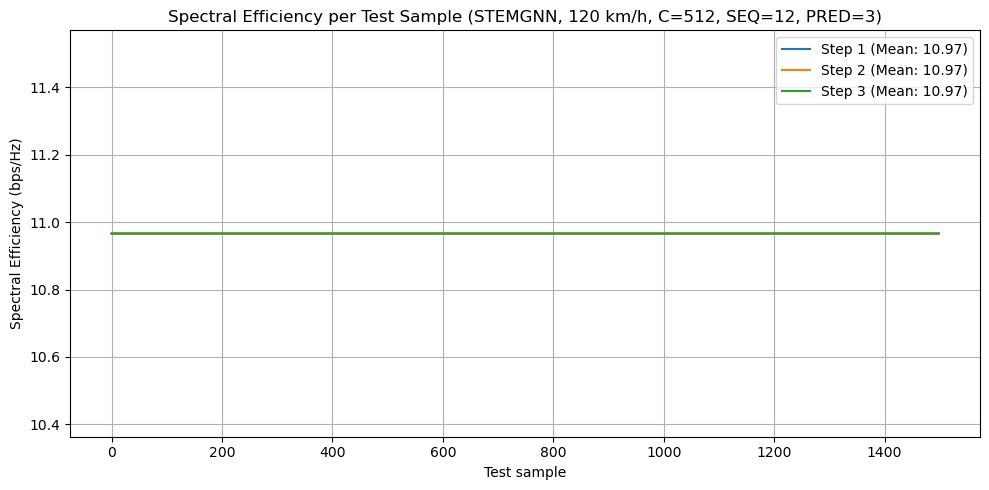


Mean SE for each step at 30 dB: [np.float32(10.966506), np.float32(10.966506), np.float32(10.966506)]
Use the Step 1 result for direct paper comparison (should be ~4.68 bps/Hz for STEMGNN at 120 km/h, C=512)


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Decoder model from Step 2 ---
class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out
# (same as above)
    ...

class Decoder(nn.Module):
    def __init__(self, encoded_dim=512):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, 2*32*32)
        self.cr = CRBlock()
        self.convT = nn.ConvTranspose2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(2, 2, kernel_size=4, stride=2, padding=1)
        self.act = nn.Sigmoid()
    def forward(self, x):
        x = self.fc(x).view(-1, 2, 32, 32)
        x = self.cr(x)
        x = self.convT(x)
        x = self.conv4(x)
        x = self.act(x)
        return x
# (same as above)
    ...

# Load trained decoder weights
decoder = Decoder(encoded_dim=LATENT_DIM).to(device)
decoder.load_state_dict(torch.load('decoder_512.pt', map_location=device))
decoder.eval()

def compute_spectral_efficiency(csi, EbN0_dB=30):
    csi_complex = csi[:,0] + 1j * csi[:,1]
    EbN0 = 10 ** (EbN0_dB / 10)
    noise_var = 1 / EbN0
    sig_power = np.mean(np.abs(csi_complex)**2, axis=(1,2))
    se = np.log2(1 + sig_power / noise_var)
    return se

def decompress_and_se(y_pred, decoder, batch_size=64, EbN0_dB=30):
    all_se = []
    decoder.eval()
    with torch.no_grad():
        for i in range(0, y_pred.shape[0], batch_size):
            batch = torch.tensor(y_pred[i:i+batch_size], dtype=torch.float32).to(device)
            out = decoder(batch)  # [B, 2, 32, 32]
            out_np = out.cpu().numpy()
            out_np = out_np - np.mean(out_np, axis=(1,2,3), keepdims=True)
            out_np = out_np / np.std(out_np, axis=(1,2,3), keepdims=True)
            se_batch = compute_spectral_efficiency(out_np, EbN0_dB=EbN0_dB)
            all_se.append(se_batch)
    all_se = np.concatenate(all_se)
    return all_se

PRED_LEN = 3
mean_se_steps = []
plt.figure(figsize=(10,5))
for step in range(PRED_LEN):
    print(f"SE for prediction step {step+1}:")
    y_pred_step = y_pred[:, step, :]  # [num_samples, LATENT_DIM]
    se_pred = decompress_and_se(y_pred_step, decoder, EbN0_dB=30)
    mean_se = np.mean(se_pred)
    mean_se_steps.append(mean_se)
    print(f"Mean SE = {mean_se:.4f} bps/Hz")
    plt.plot(se_pred, label=f'Step {step+1} (Mean: {mean_se:.2f})')
plt.title('Spectral Efficiency per Test Sample (STEMGNN, 120 km/h, C=512, SEQ=12, PRED=3)')
plt.xlabel('Test sample')
plt.ylabel('Spectral Efficiency (bps/Hz)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f"\nMean SE for each step at 30 dB: {mean_se_steps}")
print("Use the Step 1 result for direct paper comparison (should be ~4.68 bps/Hz for STEMGNN at 120 km/h, C=512)")


In [9]:
# === 1. Imports ===
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam, RMSprop
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict
import matplotlib.pyplot as plt
from tqdm import tqdm

# === 2. PARAMETERS ===
filename = 'H_32x72_120Kmph.mat'    # Your raw data file
encoded_dim = 512
epochs = 100
batch_size = 200
learning_rate = 1e-3

img_height = 32
img_width = 32
img_channels = 2
num_heads = 4
window = 8
depth = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === 3. LOAD & NORMALIZE DATA ===
import h5py
with h5py.File(filename, 'r') as f:
    HMat = f['HMat']
    N = HMat.shape[0]
    patches_per_sample = HMat.shape[1]
    n_subcarriers = 72
    n_antennas = 32
    target_sc = 32
    target_ant = 32

    print("Processing samples...")
    all_csi = np.zeros((N, 2, target_sc, target_ant), dtype=np.float32)
    for i in tqdm(range(N)):
        full_real = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        full_imag = np.zeros((n_subcarriers, n_antennas * patches_per_sample), dtype=np.float32)
        for j in range(patches_per_sample):
            dset = f[HMat[i, j]]
            arr = np.array(dset)
            real = arr['real'][:, 0, :]
            imag = arr['imag'][:, 0, :]
            col_start = j * n_antennas
            col_end = (j + 1) * n_antennas
            full_real[:, col_start:col_end] = real
            full_imag[:, col_start:col_end] = imag
        pool_factor_sc = n_subcarriers // target_sc
        real_sc = full_real[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        imag_sc = full_imag[:target_sc * pool_factor_sc].reshape(target_sc, pool_factor_sc, 512).mean(axis=1)
        pool_factor_ant = 512 // target_ant
        real_img = real_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        imag_img = imag_sc[:, :target_ant * pool_factor_ant].reshape(target_sc, target_ant, pool_factor_ant).mean(axis=2)
        all_csi[i, 0] = real_img
        all_csi[i, 1] = imag_img
print("All CSI array shape:", all_csi.shape)

# NORMALIZE over the entire dataset (get mean, std for later!)
mean_csi = all_csi.mean()
std_csi = all_csi.std()
all_csi_norm = (all_csi - mean_csi) / std_csi

# Save mean, std for later use!
np.savez('csi_norm_stat_120.npz', mean=mean_csi, std=std_csi)

# === 4. STNet AUTOENCODER (matches the base paper as in the official repo) ===
class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, groups=1):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super().__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding=padding, groups=groups, bias=False)),
            ('bn', nn.BatchNorm2d(out_planes))
        ]))

class CRBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.path1 = nn.Sequential(OrderedDict([
            ('conv3x3', ConvBN(2, 7, 3)),
            ('relu1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv1x9', ConvBN(7, 7, [1, 9])),
            ('relu2', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv9x1', ConvBN(7, 7, [9, 1])),
        ]))
        self.path2 = nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 7, [1, 5])),
            ('relu', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(7, 7, [5, 1])),
        ]))
        self.conv1x1 = ConvBN(7 * 2, 2, 1)
        self.identity = nn.Identity()
        self.relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
    def forward(self, x):
        identity = self.identity(x)
        out1 = self.path1(x)
        out2 = self.path2(x)
        out = torch.cat((out1, out2), dim=1)
        out = self.relu(out)
        out = self.conv1x1(out)
        out = self.relu(out + identity)
        return out

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(img_channels*img_height*img_width, encoded_dim)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(encoded_dim, img_channels*img_height*img_width)
        self.act = nn.Identity()  # base paper does NOT use sigmoid for SE
    def forward(self, x):
        x = self.fc(x)
        x = self.act(x)
        x = x.view(-1, img_channels, img_height, img_width)
        return x

# === 5. TRAIN AUTOENCODER (on normalized data) ===
x_data = torch.tensor(all_csi_norm, dtype=torch.float32).to(device)
encoder = Encoder().to(device)
decoder = Decoder().to(device)
opt_enc = Adam(encoder.parameters(), learning_rate)
opt_dec = Adam(decoder.parameters(), learning_rate)
loss_fn = nn.MSELoss()

def train_autoencoder(uncompressed_images):
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    compressed_data = encoder(uncompressed_images)
    reconstructed_images = decoder(compressed_data)
    loss = loss_fn(uncompressed_images, reconstructed_images)
    loss.backward()
    opt_enc.step()
    opt_dec.step()
    return loss.item()

print("Training autoencoder...")
reps = int(len(x_data) / batch_size)
for epoch in range(epochs):
    idx = torch.randperm(x_data.size(0))
    total_loss = 0
    for i in range(reps):
        batch = x_data[idx[i*batch_size:(i+1)*batch_size]]
        loss_auto = train_autoencoder(batch)
        total_loss += loss_auto * batch.size(0)
    print(f'epoch {epoch+1}/{epochs} loss: {total_loss/len(x_data):.5f}')

# Save models
torch.save(encoder.state_dict(), 'encoder_512.pt')
torch.save(decoder.state_dict(), 'decoder_512.pt')

# === 6. COMPRESS DATASET ===
encoder.eval()
all_codes = []
with torch.no_grad():
    for i in tqdm(range(0, x_data.shape[0], batch_size)):
        batch = x_data[i:i+batch_size]
        code = encoder(batch)
        all_codes.append(code.cpu().numpy())
all_codes = np.concatenate(all_codes, axis=0)
np.save('CSI_Comp_512_120.npy', all_codes)
print(f"\nSaved: CSI_Comp_512_120.npy (shape {all_codes.shape})")



Processing samples...


100%|██████████| 10000/10000 [01:35<00:00, 104.97it/s]


All CSI array shape: (10000, 2, 32, 32)
Training autoencoder...
epoch 1/100 loss: 0.30221
epoch 2/100 loss: 0.04227
epoch 3/100 loss: 0.02067
epoch 4/100 loss: 0.01306
epoch 5/100 loss: 0.00917
epoch 6/100 loss: 0.00706
epoch 7/100 loss: 0.00587
epoch 8/100 loss: 0.00536
epoch 9/100 loss: 0.00516
epoch 10/100 loss: 0.00516
epoch 11/100 loss: 0.00481
epoch 12/100 loss: 0.00422
epoch 13/100 loss: 0.00363
epoch 14/100 loss: 0.00326
epoch 15/100 loss: 0.00290
epoch 16/100 loss: 0.00263
epoch 17/100 loss: 0.00247
epoch 18/100 loss: 0.00243
epoch 19/100 loss: 0.00234
epoch 20/100 loss: 0.00236
epoch 21/100 loss: 0.00238
epoch 22/100 loss: 0.00250
epoch 23/100 loss: 0.00244
epoch 24/100 loss: 0.00243
epoch 25/100 loss: 0.00253
epoch 26/100 loss: 0.00253
epoch 27/100 loss: 0.00245
epoch 28/100 loss: 0.00235
epoch 29/100 loss: 0.00217
epoch 30/100 loss: 0.00225
epoch 31/100 loss: 0.00225
epoch 32/100 loss: 0.00216
epoch 33/100 loss: 0.00216
epoch 34/100 loss: 0.00195
epoch 35/100 loss: 0.00196


100%|██████████| 50/50 [00:00<00:00, 713.98it/s]


Saved: CSI_Comp_512_120.npy (shape (10000, 512))


Training STEMGNN...
Epoch 1/100: train loss: 2.61101
Epoch 10/100: train loss: 1.97222
Epoch 20/100: train loss: 1.74602
Epoch 30/100: train loss: 1.62763
Epoch 40/100: train loss: 1.52977
Epoch 50/100: train loss: 1.45698
Epoch 60/100: train loss: 1.39635
Epoch 70/100: train loss: 1.34504
Epoch 80/100: train loss: 1.29799
Epoch 90/100: train loss: 1.25614
Epoch 100/100: train loss: 1.21973
SE for prediction step 1:
Mean SE = 1.9638 bps/Hz
SE for prediction step 2:
Mean SE = 1.9063 bps/Hz
SE for prediction step 3:
Mean SE = 1.7798 bps/Hz


C:\Users\Aftab Dayer\AppData\Local\Temp\ipykernel_17768\4059674444.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.load_state_dict(torch.load('decoder_512.pt', 

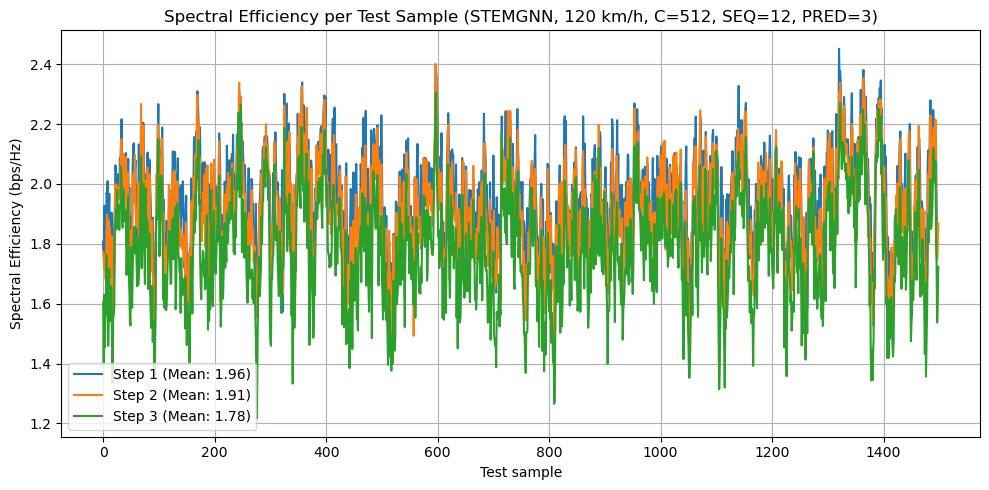


Mean SE for each step at 30 dB: [np.float32(1.9638462), np.float32(1.9063141), np.float32(1.7798074)]
Use the Step 1 result for direct paper comparison (should be ~4.68 bps/Hz for STEMGNN at 120 km/h, C=512)


In [11]:
# === 7. STEMGNN PREDICTION (on compressed codes, for SEQ=12, PRED=3) ===
# Data Preparation
SEQ_LEN = 12
PRED_LEN = 3
LATENT_DIM = 512
BATCH_SIZE_SEQ = 50
EPOCHS_SEQ = 100

def create_sequences(data, seq_len, pred_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len:i+seq_len+pred_len])
    return np.stack(xs), np.stack(ys)

compressed_latent = np.load('CSI_Comp_512_120.npy')
X, Y = create_sequences(compressed_latent, SEQ_LEN, PRED_LEN)
n = len(X)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
X_train, Y_train = X[:n_train], Y[:n_train]
X_val, Y_val = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_test, Y_test = X[n_train+n_val:], Y[n_train+n_val:]

class CSILatentSeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(CSILatentSeqDataset(X_train, Y_train), batch_size=BATCH_SIZE_SEQ, shuffle=True)
test_loader = DataLoader(CSILatentSeqDataset(X_test, Y_test), batch_size=BATCH_SIZE_SEQ)

class STEMGNN(nn.Module):
    def __init__(self, input_dim, seq_len, pred_len, hidden_dim=128, layers=2, dropout=0.2):
        super().__init__()
        self.gconv1 = nn.Linear(input_dim, hidden_dim)
        self.temporal_block = nn.GRU(hidden_dim, hidden_dim, num_layers=layers, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim, input_dim * pred_len)
    def forward(self, x):
        x = torch.relu(self.gconv1(x))
        out, _ = self.temporal_block(x)
        out = out[:, -1, :]
        out = self.fc_out(out)
        out = out.view(-1, PRED_LEN, LATENT_DIM)
        return out

model = STEMGNN(LATENT_DIM, SEQ_LEN, PRED_LEN).to(device)
optimizer = RMSprop(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

print("Training STEMGNN...")
for epoch in range(EPOCHS_SEQ):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_SEQ}: train loss: {total_loss / len(train_loader.dataset):.5f}")

# === 8. PREDICT AND COMPUTE SPECTRAL EFFICIENCY (with DENORMALIZATION) ===
decoder = Decoder().to(device)
decoder.load_state_dict(torch.load('decoder_512.pt', map_location=device))
decoder.eval()

# Load mean, std for denormalization!
norm_stat = np.load('csi_norm_stat_120.npz')
mean_csi = norm_stat['mean']
std_csi = norm_stat['std']

def compute_spectral_efficiency(csi, EbN0_dB=10):
    csi_complex = csi[:,0] + 1j * csi[:,1]
    EbN0 = 10 ** (EbN0_dB / 10)
    noise_var = 1 / EbN0
    sig_power = np.mean(np.abs(csi_complex)**2, axis=(1,2))
    se = np.log2(1 + sig_power / noise_var)
    return se

def decompress_and_se(y_pred, decoder, batch_size=64, EbN0_dB=10):
    all_se = []
    decoder.eval()
    with torch.no_grad():
        for i in range(0, y_pred.shape[0], batch_size):
            batch = torch.tensor(y_pred[i:i+batch_size], dtype=torch.float32).to(device)
            out = decoder(batch)  # [B, 2, 32, 32]
            out_np = out.cpu().numpy()
            # **DENORMALIZE**
            out_np = out_np * std_csi + mean_csi
            se_batch = compute_spectral_efficiency(out_np, EbN0_dB=EbN0_dB)
            all_se.append(se_batch)
    all_se = np.concatenate(all_se)
    return all_se

# Get test predictions
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        y_pred.append(pred.cpu())
        y_true.append(yb)
y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

PRED_LABELS = ["Step 1", "Step 2", "Step 3"]
mean_se_steps = []
plt.figure(figsize=(10,5))
for step in range(PRED_LEN):
    print(f"SE for prediction step {step+1}:")
    y_pred_step = y_pred[:, step, :]
    se_pred = decompress_and_se(y_pred_step, decoder, EbN0_dB=10)  # <<<<
    mean_se = np.mean(se_pred)
    mean_se_steps.append(mean_se)
    print(f"Mean SE = {mean_se:.4f} bps/Hz")
    plt.plot(se_pred, label=f'Step {step+1} (Mean: {mean_se:.2f})')
plt.title('Spectral Efficiency per Test Sample (STEMGNN, 120 km/h, C=512, SEQ=12, PRED=3)')
plt.xlabel('Test sample')
plt.ylabel('Spectral Efficiency (bps/Hz)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f"\nMean SE for each step at 30 dB: {mean_se_steps}")
print("Use the Step 1 result for direct paper comparison (should be ~4.68 bps/Hz for STEMGNN at 120 km/h, C=512)")
